# Homework 4

In [27]:
import numpy as np
import scipy.sparse as sp
import json
import pandas as pd

In [29]:
metadata = pd.read_csv('embeddings/metadata.csv')
metadata

,idx,INSTRUCTION,RESPONSE,SOURCE,METADATA
0,0,"hi, is there a CLI command to roll back any up...",your recourse is to re-install fresh the older...,ubuntu-dialogue,"{""user_question"": ""edd"", ""user_answer"": ""n8tus..."
1,1,A LiveCD iso can be burned to a DVD-R and run ...,"I hope so, or the custom DVDs I've done are wo...",ubuntu-dialogue,"{""user_question"": ""usrl"", ""user_answer"": ""Ghos..."
2,2,"hello, is there a way to adjust gamma settings...",for me i have my nvidia settings manager and i...,ubuntu-dialogue,"{""user_question"": ""nucco_"", ""user_answer"": ""sp..."
3,3,does ubuntu come with a firewall by default?,no iptables rule is loaded by deault on ubuntu,ubuntu-dialogue,"{""user_question"": ""aeleon"", ""user_answer"": ""er..."
4,4,Can someone tell me howto get rid of Google Ch...,sudo dpkg -l |grep -i chrom ----> sudo apt-get...,ubuntu-dialogue,"{""user_question"": ""frold"", ""user_answer"": ""shi..."
...,...,...,...,...,...
16168,16168,is there any GUI irc client besides pidgin ?,xchat,ubuntu-dialogue,"{""user_question"": ""jameela"", ""user_answer"": ""p..."
16169,16169,"Hello , if I have a log file and i like to see...",you can try watch 'tail /path/to/logfile',ubuntu-dialogue,"{""user_question"": ""Zedde"", ""user_answer"": ""ada..."
16170,16170,guys im trying to install itask but when i try...,sudo aptitude install automake autoconf build-...,ubuntu-dialogue,"{""user_question"": ""silvernode"", ""user_answer"":..."
16171,16171,is there anyway to recurse with sftp in it's n...,"I believe not, but try lftp instead (it suppor...",ubuntu-dialogue,"{""user_question"": ""psion"", ""user_answer"": ""Sev..."


In [2]:


def load_embedding(code):
    loaded = np.load(f'embeddings/{code}_embeddings.npz', allow_pickle=True)
    with open(f'embeddings/{code}_info.json', encoding='utf-8') as f:
        info = json.load(f)

    if 'X_instruction_data' in loaded:
        X = sp.csr_matrix(
            (loaded['X_instruction_data'], loaded['X_instruction_indices'],
             loaded['X_instruction_indptr']),
            shape=tuple(loaded['X_instruction_shape'])
        )
        is_sparse = True
    else:
        X = loaded['X_instruction']
        is_sparse = False

    return X, info, is_sparse


# ---- Load & Check Sparse vs Dense ----
methods = ['bow', 'tfidf', 'w2v', 'fasttext', 'bert', 'OpenAI']
data = {}

print(f"\n{'Method':<10} {'Samples':>8} {'Dims':>7} {'Type':<8}")
print("-" * 40)

for m in methods:
    X, info, is_sparse = load_embedding(m)
    data[m] = {'X': X, 'is_sparse': is_sparse}
    matrix_type = 'Sparse' if is_sparse else 'Dense'
    print(f"{m:<10} {X.shape[0]:>8,} {X.shape[1]:>7,} {matrix_type:<8}")


Method      Samples    Dims Type    
----------------------------------------
bow          16,173   3,000 Sparse  
tfidf        16,173   3,000 Sparse  
w2v          16,173     200 Dense   
fasttext     16,173     200 Dense   
bert         16,173     384 Dense   
OpenAI       16,173   1,536 Dense   


In [ ]:
bow = data['bow']['X']
tfidf = data['tfidf']['X']
w2v = data['w2v']['X']
fasttext = data['fasttext']['X']
bert: np.ndarray = data['bert']['X']
openai = data['OpenAI']['X']

In [8]:
bert

array([[-0.00596187, -0.01657574,  0.00570875, ..., -0.03068376,
         0.00591518, -0.00697561],
       [ 0.01671674,  0.01031567, -0.08575841, ..., -0.09280229,
         0.07785884,  0.0540279 ],
       [-0.00635472, -0.09555202, -0.00791311, ..., -0.0164427 ,
        -0.03695422, -0.0015349 ],
       ...,
       [-0.03980771,  0.04605321,  0.00935406, ...,  0.01861468,
        -0.02176332, -0.04796488],
       [ 0.02191279, -0.03294546, -0.02390196, ...,  0.0610736 ,
         0.06099329,  0.04775466],
       [-0.04409125, -0.04351008, -0.00607673, ...,  0.09986144,
        -0.01095774,  0.01365945]], shape=(16173, 384), dtype=float32)

In [9]:
bow

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 344688 stored elements and shape (16173, 3000)>

In [15]:
from sklearn.preprocessing import normalize

normalized_w2v = normalize(w2v, norm='l2')
normalized_fasttext = normalize(fasttext, norm='l2')
normalized_bert = normalize(bert, norm='l2')
normalized_openai = normalize(openai, norm='l2')

In [16]:
np.linalg.norm(normalized_bert, axis=1)

array([1.        , 1.        , 1.        , ..., 1.0000001 , 1.        ,
       0.99999994], shape=(16173,), dtype=float32)

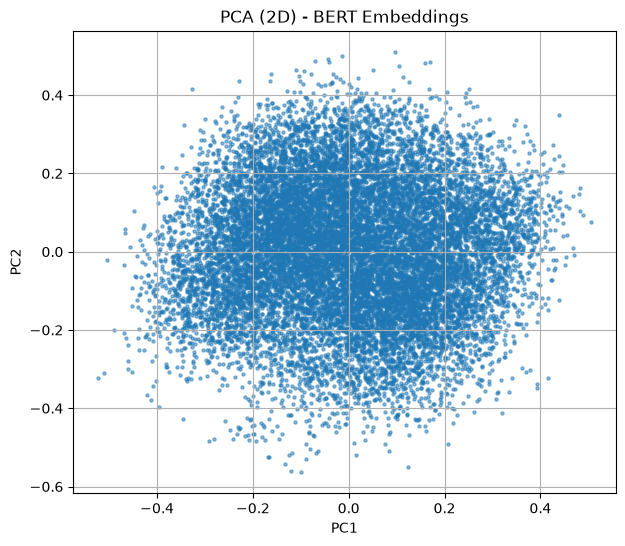

In [18]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2, random_state=42)
bert_pca = pca.fit_transform(normalized_bert)

plt.figure(figsize=(7,6))
plt.scatter(bert_pca[:, 0], bert_pca[:, 1], s=5, alpha=0.5)
plt.title("PCA (2D) - BERT Embeddings")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True)
plt.show()

Takes more time. because T-SNE is an iterative algorithm

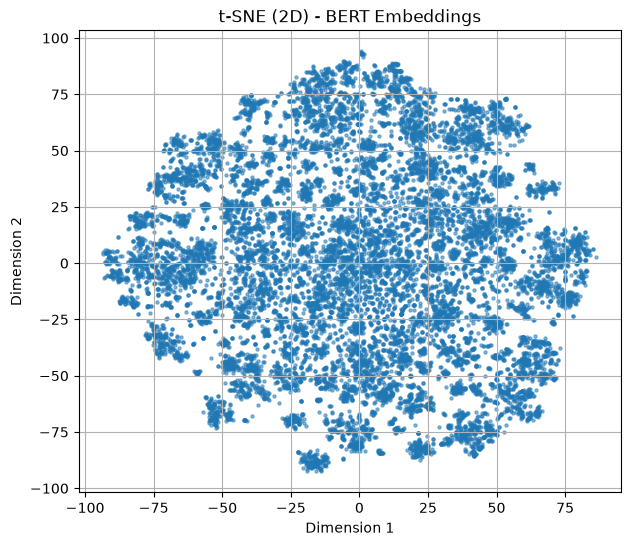

In [19]:
from sklearn.manifold import TSNE

tsne = TSNE(
    n_components=2,
    metric='cosine',
    random_state=42,
    init='pca'
)

bert_tsne = tsne.fit_transform(normalized_bert)

plt.figure(figsize=(7,6))
plt.scatter(bert_tsne[:, 0], bert_tsne[:, 1], s=5, alpha=0.5)
plt.title("t-SNE (2D) - BERT Embeddings")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.grid(True)
plt.show()

Ineria = sum of squared distance points of their centroids

In [21]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

ks = range(25, 36)

inertias = []
silhouettes = []

for k in ks:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(normalized_bert)

    inertias.append(kmeans.inertia_)
    silhouettes.append(
        silhouette_score(
            normalized_bert,
            labels,
            metric='cosine'
        )
    )

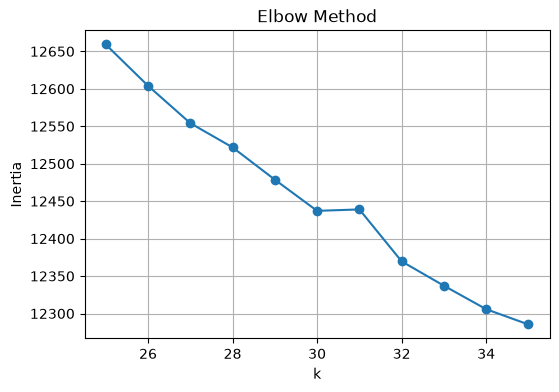

In [22]:
plt.figure(figsize=(6,4))
plt.plot(ks, inertias, marker='o')
plt.xlabel("k")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.grid(True)
plt.show()

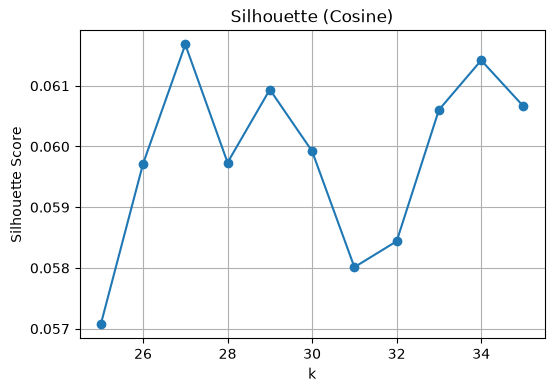

In [23]:
plt.figure(figsize=(6,4))
plt.plot(ks, silhouettes, marker='o')
plt.xlabel("k")
plt.ylabel("Silhouette Score")
plt.title("Silhouette (Cosine)")
plt.grid(True)
plt.show()

In [24]:
best_k = ks[silhouettes.index(max(silhouettes))]
print("Best k =", best_k)
print("Best silhouette =", max(silhouettes))

Best k = 27
Best silhouette = 0.061679139733314514


In [31]:
kmeans = KMeans(n_clusters=best_k, random_state=42)
labels = kmeans.fit_predict(normalized_bert)
labels

array([15, 17,  2, ..., 18,  7, 22], shape=(16173,), dtype=int32)

In [33]:
metadata["cluster"] = labels
metadata

,idx,INSTRUCTION,RESPONSE,SOURCE,METADATA,cluster
0,0,"hi, is there a CLI command to roll back any up...",your recourse is to re-install fresh the older...,ubuntu-dialogue,"{""user_question"": ""edd"", ""user_answer"": ""n8tus...",15
1,1,A LiveCD iso can be burned to a DVD-R and run ...,"I hope so, or the custom DVDs I've done are wo...",ubuntu-dialogue,"{""user_question"": ""usrl"", ""user_answer"": ""Ghos...",17
2,2,"hello, is there a way to adjust gamma settings...",for me i have my nvidia settings manager and i...,ubuntu-dialogue,"{""user_question"": ""nucco_"", ""user_answer"": ""sp...",2
3,3,does ubuntu come with a firewall by default?,no iptables rule is loaded by deault on ubuntu,ubuntu-dialogue,"{""user_question"": ""aeleon"", ""user_answer"": ""er...",7
4,4,Can someone tell me howto get rid of Google Ch...,sudo dpkg -l |grep -i chrom ----> sudo apt-get...,ubuntu-dialogue,"{""user_question"": ""frold"", ""user_answer"": ""shi...",5
...,...,...,...,...,...,...
16168,16168,is there any GUI irc client besides pidgin ?,xchat,ubuntu-dialogue,"{""user_question"": ""jameela"", ""user_answer"": ""p...",11
16169,16169,"Hello , if I have a log file and i like to see...",you can try watch 'tail /path/to/logfile',ubuntu-dialogue,"{""user_question"": ""Zedde"", ""user_answer"": ""ada...",0
16170,16170,guys im trying to install itask but when i try...,sudo aptitude install automake autoconf build-...,ubuntu-dialogue,"{""user_question"": ""silvernode"", ""user_answer"":...",18
16171,16171,is there anyway to recurse with sftp in it's n...,"I believe not, but try lftp instead (it suppor...",ubuntu-dialogue,"{""user_question"": ""psion"", ""user_answer"": ""Sev...",7


In [44]:
metadata[metadata['cluster'] == 0].head(5)

,idx,INSTRUCTION,RESPONSE,SOURCE,METADATA,cluster
10,10,What's the best way for a bash script to pick ...,"if not, parse it",ubuntu-dialogue,"{""user_question"": ""steve176"", ""user_answer"": ""...",0
45,45,How can I append something to an enviroment va...,VARIABLE=$VARIABLE:blah ?,ubuntu-dialogue,"{""user_question"": ""Vadi"", ""user_answer"": ""cred...",0
104,104,"YO! Whilst in the command line, when I enter a...",home and end work for me,ubuntu-dialogue,"{""user_question"": ""sagredo"", ""user_answer"": ""z...",0
105,105,ATTN ALL BASH h4x0rz: how can I select all ins...,ctrl-u?,ubuntu-dialogue,"{""user_question"": ""sagredo"", ""user_answer"": ""r...",0
153,153,in the top command what does the %wa mean? it ...,%wa is wait time,ubuntu-dialogue,"{""user_question"": ""neil"", ""user_answer"": ""Only...",0


In [45]:
cluster_id = 0

for i, row in enumerate(metadata[metadata['cluster'] == cluster_id].head(5).itertuples(index=False), 1):
    print(f"Sample {i}")
    print("INSTRUCTION:")
    print(row.INSTRUCTION)
    print()
    print("RESPONSE:")
    print(row.RESPONSE)
    print("=" * 100)

Sample 1
INSTRUCTION:
What's the best way for a bash script to pick up variables from /etc/environment? Should I just use source?

RESPONSE:
if not, parse it
Sample 2
INSTRUCTION:
How can I append something to an enviroment variable?

RESPONSE:
VARIABLE=$VARIABLE:blah ?
Sample 3
INSTRUCTION:
YO! Whilst in the command line, when I enter a long string of characters, how can I instantly jump to the very front of the line?

RESPONSE:
home and end work for me
Sample 4
INSTRUCTION:
ATTN ALL BASH h4x0rz: how can I select all inside of the terminal

RESPONSE:
ctrl-u?
Sample 5
INSTRUCTION:
in the top command what does the %wa mean? it seems high to me

RESPONSE:
%wa is wait time


In [46]:
cluster_id = 1

for i, row in enumerate(metadata[metadata['cluster'] == cluster_id].head(5).itertuples(index=False), 1):
    print(f"Sample {i}")
    print("INSTRUCTION:")
    print(row.INSTRUCTION)
    print()
    print("RESPONSE:")
    print(row.RESPONSE)
    print("=" * 100)

Sample 1
INSTRUCTION:
hi. could anyone please give me a quick hint on how to install the adobe flash pugin for firefox in hardy?

RESPONSE:
find out it's name (enter about:plugins as the URL, it ends in .so)
Sample 2
INSTRUCTION:
Guys where can i find adobe flash x64? I installed both from software center but got the same i386 crap

RESPONSE:
I am just curious why do you need x64 flash?
Sample 3
INSTRUCTION:
Is there any way to have Firefox report itself as IE to a website?

RESPONSE:
user agent switcher https://addons.mozilla.org/en-US/firefox/search?q=user+agent&cat=all
Sample 4
INSTRUCTION:
hello everybody, i have a problem about gnash. When I open youtube in firefox, my computer choked, gnash uses more than 50% of cpu, how can i deal it except uninstall gnash?

RESPONSE:
But you may want to ask the gnash people
Sample 5
INSTRUCTION:
hello, i need a console browser (not lynx, please) any suggestions?

RESPONSE:
elinks


In [47]:
cluster_id = 2

for i, row in enumerate(metadata[metadata['cluster'] == cluster_id].head(5).itertuples(index=False), 1):
    print(f"Sample {i}")
    print("INSTRUCTION:")
    print(row.INSTRUCTION)
    print()
    print("RESPONSE:")
    print(row.RESPONSE)
    print("=" * 100)

Sample 1
INSTRUCTION:
hello, is there a way to adjust gamma settings in totem? my videos aren't playing with the correct colours

RESPONSE:
for me i have my nvidia settings manager and i change the video gamma settings from there...
Sample 2
INSTRUCTION:
hi folks. i am trying to convert screencast I made to mpeg4     but when I try    ffmpeg -i ~/out.mpg -ar 22050 blah.mp4          I get Unsupported codec for output     .   Any clue which package I need for this?

RESPONSE:
you probably the ffmpeg binaries from medibuntu to get mp4 support due to patent issues
Sample 3
INSTRUCTION:
!alis | raven i'd search for a mplayer/mencoder channel if i where you

RESPONSE:
In previous versions of Ubuntu they didn't treat USB drives differently, now they do. I personally wish that they would always default to installing grub's boot sector to the MBR of the drive containing Ubuntu, and there is no technical problem preventing them from doing so, they have just decided not to do things that way.
Sam

In [48]:
cluster_id = 3

for i, row in enumerate(metadata[metadata['cluster'] == cluster_id].head(5).itertuples(index=False), 1):
    print(f"Sample {i}")
    print("INSTRUCTION:")
    print(row.INSTRUCTION)
    print()
    print("RESPONSE:")
    print(row.RESPONSE)
    print("=" * 100)

Sample 1
INSTRUCTION:
wow. for the life of me i can never remember this command. whats the command that outputs your ati hardare information? shows if you have direct rendering?

RESPONSE:
glxinfo | grep dri ?
Sample 2
INSTRUCTION:
is there a graphical way to search for an nfs server on gutsy?

RESPONSE:
does Places > Network work for you?
Sample 3
INSTRUCTION:
whats the human readable command for hardware info?

RESPONSE:
I'm sure you can guess ls hw :)
Sample 4
INSTRUCTION:
how do i see the system statistics for my CPU and video card? i need to know how fast it thinks my video card and CPU are

RESPONSE:
cat /proc/cpuinfo   for cpu, not sure what gfx card would be
Sample 5
INSTRUCTION:
How can I print out all of the enviroment variables that are set on my computer?

RESPONSE:
thats it, env


In [49]:
cluster_id = 4

for i, row in enumerate(metadata[metadata['cluster'] == cluster_id].head(5).itertuples(index=False), 1):
    print(f"Sample {i}")
    print("INSTRUCTION:")
    print(row.INSTRUCTION)
    print()
    print("RESPONSE:")
    print(row.RESPONSE)
    print("=" * 100)

Sample 1
INSTRUCTION:
is there a way to see if a hard disk has bad blocks on ubuntu? fsck does the job?

RESPONSE:
have you considered, however, monitoring your HD's state using the SMART sensors? (the 'smartmontools' package can be used to query them)
Sample 2
INSTRUCTION:
Hi, My Western Digital USB Passport Drive doesn't appear under ubuntu 7.10. Works fine in XP and from earlier versions of Ubuntu. Any ideas?

RESPONSE:
I have one of those too.. it works nicely in ubuntu... needs a properly power-supplied usb port though
Sample 3
INSTRUCTION:
whats the command to detect drives connected again?

RESPONSE:
sudo fdisk -l   .  or just 'mount' to see what's mounted
Sample 4
INSTRUCTION:
can anyone help me set up gtkpod? I am trying to figure out the ipod's mount point. I can see it on my desktop, but I don't know how to find out where it's mounted.

RESPONSE:
''mount''
Sample 5
INSTRUCTION:
can anyone tell me how to make my extra internal hard drive automatically mount when i log in?

RE